In [1]:
import pyro.distributions as dist
import pyro
from pyro.ops.indexing import Vindex
import torch
from pyro.infer.autoguide import AutoNormal, AutoDelta
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.optim import Adam
from pyro import poutine

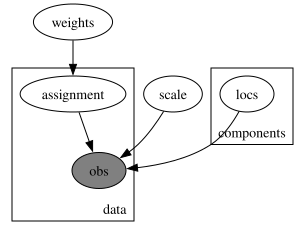

In [2]:
K = 3
data = torch.tensor([0.0, 1.0, 10.0, 11.0, 12.0])


@config_enumerate
def tutorial_model(data):
    # Global variables.
    weights = pyro.sample("weights", dist.Dirichlet(0.5 * torch.ones(K)))
    scale = pyro.sample("scale", dist.LogNormal(0.0, 2.0))
    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(0.0, 10.0))

    with pyro.plate("data", len(data)):
        # Local variables.
        assignment = pyro.sample("assignment", dist.Categorical(weights))
        pyro.sample("obs", dist.Normal(locs[assignment], scale), obs=data)


pyro.render_model(tutorial_model, (data,))

In [3]:

tutorial_guide = AutoNormal(poutine.block(tutorial_model, hide=["assignment"]))
loss = TraceEnum_ELBO(max_plate_nesting=1)
optim = Adam({"lr": 0.003})
data = torch.tensor([0.0, 1.0, 10.0, 11.0, 12.0])

svi = SVI(tutorial_model, tutorial_guide, optim, loss)
for k in range(1000):
    svi.step(data)
    if k % 100 == 0:
        print(".", end="")

..........

In [4]:
guide_trace = poutine.trace(tutorial_guide).get_trace(data)  # record the globals
trained_model = poutine.replay(tutorial_model, trace=guide_trace)  # replay the globals
inferred_model = infer_discrete(trained_model, temperature=1, first_available_dim=-2)
trace = poutine.trace(inferred_model).get_trace(data)
trace.nodes["assignment"]["value"]

tensor([1, 1, 0, 1, 0])

In [10]:
# spike_slab_prior_probs = torch.tensor([[[0.05, 1.0]]]).expand(3, 5, -1)
# spike_slab_prior_scales = torch.tensor([[[0.9, 0.1]]]).expand(3, 5, -1)

spike_slab_prior_probs = torch.tensor([0.05, 1.0])
spike_slab_prior_scales = torch.tensor([0.05, 1.0])

# print(spike_slab_prior_scales.shape)


def create_plates():
    return (
        pyro.plate("inner", 3, dim=-1),
        pyro.plate("outer", 5, dim=-2),
    )


def model():
    inner_plate, outer_plate = create_plates()
    with inner_plate as idx:
        mix_dist = dist.Categorical(probs=spike_slab_prior_probs)
        has_effect = pyro.sample("has_effect", mix_dist, infer={"enumerate": "parallel"})
        mix_scales = Vindex(spike_slab_prior_scales)[..., has_effect]
        beta = pyro.sample("element_effects", dist.Normal(0.0, mix_scales))
        return has_effect, beta


def model():
    mix_dist = dist.Categorical(probs=spike_slab_prior_probs)
    has_effect = pyro.sample("has_effect", mix_dist, infer={"enumerate": "parallel"})
    mix_scales = spike_slab_prior_scales[has_effect]
    beta = pyro.sample("element_effects", dist.Normal(0.0, mix_scales))
    return has_effect, beta


pyro.render_model(model)

ValueError: Expected reinterpreted_batch_ndims <= len(base_distribution.batch_shape), actual 1 vs 0
  Trace Shapes:  
   Param Sites:  
  Sample Sites:  
has_effect dist |
          value |

In [6]:
model()

(tensor(1), tensor(1.2237))

In [7]:
guide = AutoDelta(poutine.block(model, hide=["has_effect"]))
guide()

{'element_effects': tensor(-0.0549, grad_fn=<ExpandBackward0>)}

In [8]:
loss = TraceEnum_ELBO(max_plate_nesting=1)
optim = Adam({"lr": 0.003})
svi = SVI(model, guide, optim, loss)
for k in range(1000):
    svi.step()
    if k % 100 == 0:
        print(".", end="")

..........

In [9]:
guide_trace = poutine.trace(guide).get_trace()  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals
inferred_model = infer_discrete(trained_model, temperature=1, first_available_dim=-2)
trace = poutine.trace(inferred_model).get_trace()

ValueError: Error while packing tensors at site 'element_effects':
  Invalid tensor shape.
  Allowed dims: 
  Actual shape: (2, 1)
  Try adding shape assertions for your model's sample values and distribution parameters.
       Trace Shapes:      
        Param Sites:      
       Sample Sites:      
     has_effect dist     |
               value 2 1 |
            log_prob 2 1 |
element_effects dist 2 1 |
               value     |
            log_prob 2 1 |
Trace Shapes:
 Param Sites:
Sample Sites: